# Handwritten Digit Recognition using MNIST Dataset

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [4]:
# Load MNIST dataset
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training set shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Test set shape: (10000, 28, 28)
Test labels shape: (10000,)


In [5]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Normalized training data min: {X_train.min()}, max: {X_train.max()}")
print(f"Normalized test data min: {X_test.min()}, max: {X_test.max()}")

Normalized training data min: 0.0, max: 1.0
Normalized test data min: 0.0, max: 1.0


In [6]:
# Build Neural Network
model = Sequential([
    Flatten(input_shape=(28, 28)),      # Convert 2D image to 1D
    Dense(128, activation='relu'),      # Hidden layer with 128 units
    Dense(10, activation='softmax')     # Output layer for digits 0-9
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Train model
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9274 - loss: 0.2530
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9669 - loss: 0.1119
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9775 - loss: 0.0759
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0571
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9863 - loss: 0.0447


In [9]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9767 - loss: 0.0783

Test Loss: 0.0783
Test Accuracy: 0.9767


In [10]:
# Predict on test data
predictions = model.predict(X_test)

# Get predicted digit for the first test image
predicted_digit = predictions[0].argmax()
actual_digit = y_test[0]

print(f"\nPredicted Digit: {predicted_digit}")
print(f"Actual Digit: {actual_digit}")
print(f"Prediction Confidence: {predictions[0][predicted_digit]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Predicted Digit: 7
Actual Digit: 7
Prediction Confidence: 0.9999


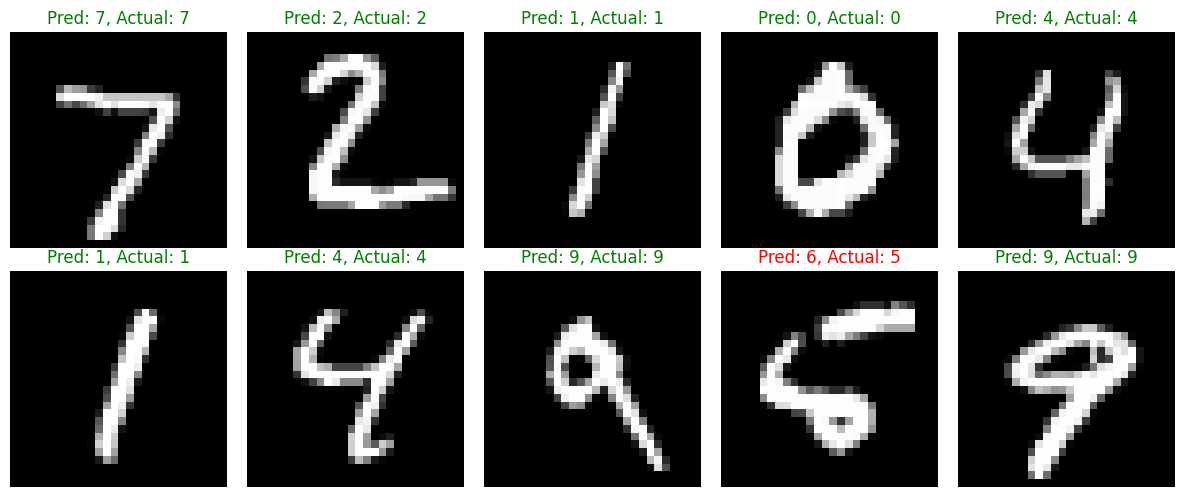

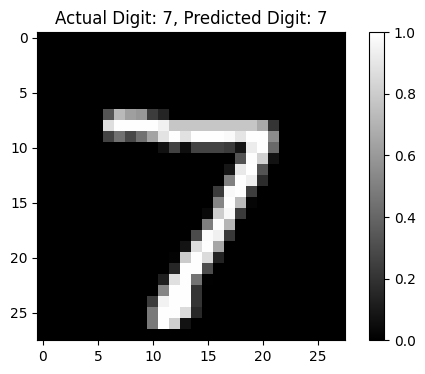

In [11]:
# Visualize predictions with grid of images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_test[i], cmap='gray')
    pred_digit = predictions[i].argmax()
    actual_digit = y_test[i]
    color = 'green' if pred_digit == actual_digit else 'red'
    axes[i].set_title(f'Pred: {pred_digit}, Actual: {actual_digit}', color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Visualize a single test image
plt.figure(figsize=(6, 4))
plt.imshow(X_test[0], cmap='gray')
plt.title(f'Actual Digit: {y_test[0]}, Predicted Digit: {predictions[0].argmax()}')
plt.colorbar()
plt.show()